In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("../data/yellow_tripdata_2026.csv")
df

C:\Users\Linh\AppData\Local\Temp\ipykernel_2556\3963665272.py:1: DtypeWarning: Columns (0: store_and_fwd_flag) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/yellow_tripdata_2026.csv")


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-01 00:54:04,2026-01-01 00:59:37,1.0,0.97,1.0,N,239,238,1,7.20,1.00,0.5,3.66,0.0,1.0,15.86,2.5,0.0,0.00
1,2,2026-01-01 00:15:22,2026-01-01 00:58:10,4.0,5.58,1.0,N,142,209,1,38.70,1.00,0.5,11.11,0.0,1.0,55.56,2.5,0.0,0.75
2,2,2026-01-01 00:47:11,2026-01-01 01:00:47,2.0,2.33,1.0,N,144,137,1,14.20,1.00,0.5,4.99,0.0,1.0,24.94,2.5,0.0,0.75
3,1,2026-01-01 00:17:54,2026-01-01 00:28:32,1.0,1.30,1.0,N,142,50,2,11.40,4.25,0.5,0.00,0.0,1.0,17.15,2.5,0.0,0.75
4,2,2026-01-01 00:34:14,2026-01-01 01:11:58,1.0,5.34,1.0,N,161,45,1,37.30,1.00,0.5,8.61,0.0,1.0,51.66,2.5,0.0,0.75
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10444712,2,2026-03-31 23:10:43,2026-03-31 23:33:02,NaN,8.47,NaN,NaN,13,263,0,50.14,0.00,0.5,0.00,0.0,1.0,60.37,NaN,NaN,0.75
10444713,2,2026-03-31 23:41:22,2026-03-31 23:52:36,NaN,1.99,NaN,NaN,24,42,0,12.32,0.00,0.5,0.00,0.0,1.0,13.82,NaN,NaN,0.00
10444714,2,2026-03-31 23:39:38,2026-04-01 00:13:44,NaN,10.21,NaN,NaN,62,237,0,47.95,0.00,0.5,0.00,0.0,1.0,52.70,NaN,NaN,0.75
10444715,2,2026-03-31 23:57:57,2026-04-01 00:29:33,NaN,7.87,NaN,NaN,61,141,0,49.93,0.00,0.5,0.00,0.0,1.0,53.93,NaN,NaN,0.00


In [3]:
taxi_zone = pd.read_csv("../data/taxi_zone_lookup.csv")
taxi_zone

,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone
...,...,...,...,...
260,261,Manhattan,World Trade Center,Yellow Zone
261,262,Manhattan,Yorkville East,Yellow Zone
262,263,Manhattan,Yorkville West,Yellow Zone
263,264,Unknown,NaN,NaN


In [4]:
taxi_zone.isnull().sum()

LocationID      0
Borough         1
Zone            1
service_zone    2
dtype: int64

In [5]:
taxi_zone[taxi_zone.isna().any(axis=1)]

,LocationID,Borough,Zone,service_zone
263,264,Unknown,NaN,NaN
264,265,NaN,Outside of NYC,NaN


In [6]:
taxi_zone["Borough"] = (
    taxi_zone["Borough"]
    .fillna("Unknown")
)

taxi_zone["Zone"] = (
    taxi_zone["Zone"]
    .fillna("Unknown")
)

taxi_zone["service_zone"] = (
    taxi_zone["service_zone"]
    .fillna("Unknown")
)

In [7]:
df["tpep_pickup_datetime"] = pd.to_datetime(
    df["tpep_pickup_datetime"]
)
df["tpep_dropoff_datetime"] = pd.to_datetime(
    df["tpep_dropoff_datetime"]
)

In [8]:
taxi_zone['Borough'].value_counts()

Borough
Queens           69
Manhattan        69
Brooklyn         61
Bronx            43
Staten Island    20
Unknown           2
EWR               1
Name: count, dtype: int64

# Pickup Hotspots 

In [9]:
pickup_hotspots = (
    df
    .groupby("PULocationID")
    .size()
    .reset_index(name="trip_count")
    .sort_values(
        "trip_count",
        ascending=False
    )
)

pickup_hotspots.head(20)

,PULocationID,trip_count
233,237,455545
232,236,424564
157,161,424343
128,132,404393
182,186,315120
158,162,313631
138,142,300270
226,230,295879
78,79,285827
230,234,272286


In [10]:
pickup_hotspot = pickup_hotspots.merge(
    taxi_zone,
    left_on="PULocationID",
    right_on="LocationID"
)

In [11]:
pickup_hotspot

,PULocationID,trip_count,LocationID,Borough,Zone,service_zone
0,237,455545,237,Manhattan,Upper East Side South,Yellow Zone
1,236,424564,236,Manhattan,Upper East Side North,Yellow Zone
2,161,424343,161,Manhattan,Midtown Center,Yellow Zone
3,132,404393,132,Queens,JFK Airport,Airports
4,186,315120,186,Manhattan,Penn Station/Madison Sq West,Yellow Zone
...,...,...,...,...,...,...
257,99,4,99,Staten Island,Freshkills Park,Boro Zone
258,44,4,44,Staten Island,Charleston/Tottenville,Boro Zone
259,5,3,5,Staten Island,Arden Heights,Boro Zone
260,105,2,105,Manhattan,Governor's Island/Ellis Island/Liberty Island,Yellow Zone


In [12]:
top_pickup = pickup_hotspot[
    [
        "Zone",
        "Borough",
        "trip_count"
    ]
]


top_pickup.head(20)

,Zone,Borough,trip_count
0,Upper East Side South,Manhattan,455545
1,Upper East Side North,Manhattan,424564
2,Midtown Center,Manhattan,424343
3,JFK Airport,Queens,404393
4,Penn Station/Madison Sq West,Manhattan,315120
5,Midtown East,Manhattan,313631
6,Lincoln Square East,Manhattan,300270
7,Times Sq/Theatre District,Manhattan,295879
8,East Village,Manhattan,285827
9,Union Sq,Manhattan,272286


In [13]:
top20 = top_pickup.sort_values(
    by="trip_count",
    ascending=False
).head(20)

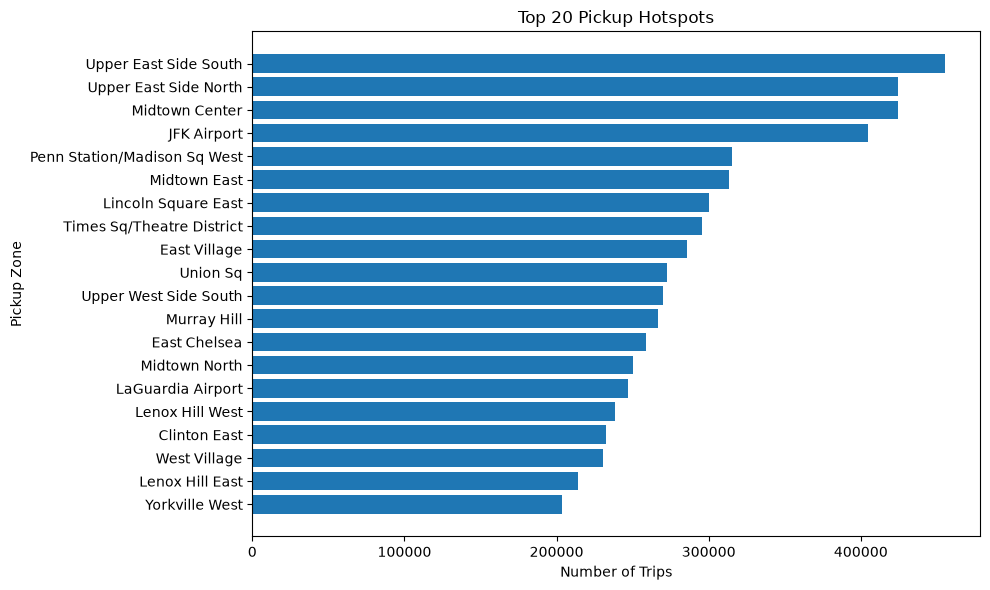

In [14]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))

plt.barh(
    top20["Zone"],
    top20["trip_count"]
)

plt.gca().invert_yaxis()

plt.xlabel("Number of Trips")
plt.ylabel("Pickup Zone")
plt.title("Top 20 Pickup Hotspots")

plt.tight_layout()
plt.show()

#### Nhận xét:
1. Zone phổ biến nhất 
- Upper East Side South là khu vực có số lượng chuyến đón cao nhất với 455.545 chuyến. Upper East Side South là khu vực có nhu cầu đón taxi cao nhất trong bộ dữ liệu, cho thấy đây là một trong những điểm tập trung hành khách và hoạt động giao thông sôi động nhất của thành phố.
- Tiếp theo là Upper East Side North (424.564 chuyến) và Midtown Center (424.343 chuyến), hai khu vực này gần như ngang nhau và đều thấp hơn khu vực đứng đầu khoảng 31.000 chuyến.
2. Mức độ tập trung của nhu cầu 
- Top 5 khu vực đều có số chuyến đón trên 310.000 chuyến.Sau nhóm dẫn đầu, số chuyến giảm dần xuống khoảng 200.000 chuyến ở cuối Top 20. Có sự chênh lệch đáng kể giữa nhóm đầu và nhóm cuối.

=> Nhu cầu đón taxi tập trung chủ yếu ở một số khu vực nhất định thay vì phân bố đồng đều trên toàn thành phố. Một số ít khu vực tạo ra phần lớn số chuyến đón.

3. Khu vực địa lý nổi bật: Manhattan chiếm ưu thế tuyệt đối về số lượng điểm đón khách trong Top 20, trong khi các quận khác chỉ đóng góp một số ít khu vực nổi bật. Điều này cho thấy nhu cầu sử dụng taxi tập trung chủ yếu tại Manhattan bởi Manhattan là trung tâm tài chính, thương mại và du lịch nên tập trung rất nhiều hoạt động di chuyển.
4. Ảnh hưởng của sân bay:
- JFK Airport nằm trong Top 5.
- LaGuardia Airport cũng nằm trong Top 20.

=> Hai sân bay lớn đều nằm trong nhóm các điểm đón khách đông nhất, cho thấy sân bay là những đầu mối giao thông quan trọng với lượng hành khách di chuyển rất lớn.

# Dropoff Hotspots 

In [15]:
dropoff_hotspots = (
    df
    .groupby("DOLocationID")
    .size()
    .reset_index(name="trip_count")
    .sort_values(
        "trip_count",
        ascending=False
    )
)

dropoff_hotspots.head(20)

,DOLocationID,trip_count
231,236,439978
232,237,414474
157,161,340458
166,170,286049
234,239,272956
137,141,268473
138,142,267765
225,230,267654
67,68,257253
158,162,255928


In [16]:
top_dropoff = (
    df.groupby("DOLocationID")
    .size()
    .reset_index(name="trip_count")
    .sort_values(
        "trip_count",
        ascending=False
    )
    .head(20)
)

In [17]:
top_dropoff = top_dropoff.merge(
    taxi_zone,
    left_on="DOLocationID",
    right_on="LocationID",
    how="left"
)

In [18]:
top_dropoff 

,DOLocationID,trip_count,LocationID,Borough,Zone,service_zone
0,236,439978,236,Manhattan,Upper East Side North,Yellow Zone
1,237,414474,237,Manhattan,Upper East Side South,Yellow Zone
2,161,340458,161,Manhattan,Midtown Center,Yellow Zone
3,170,286049,170,Manhattan,Murray Hill,Yellow Zone
4,239,272956,239,Manhattan,Upper West Side South,Yellow Zone
5,141,268473,141,Manhattan,Lenox Hill West,Yellow Zone
6,142,267765,142,Manhattan,Lincoln Square East,Yellow Zone
7,230,267654,230,Manhattan,Times Sq/Theatre District,Yellow Zone
8,68,257253,68,Manhattan,East Chelsea,Yellow Zone
9,162,255928,162,Manhattan,Midtown East,Yellow Zone


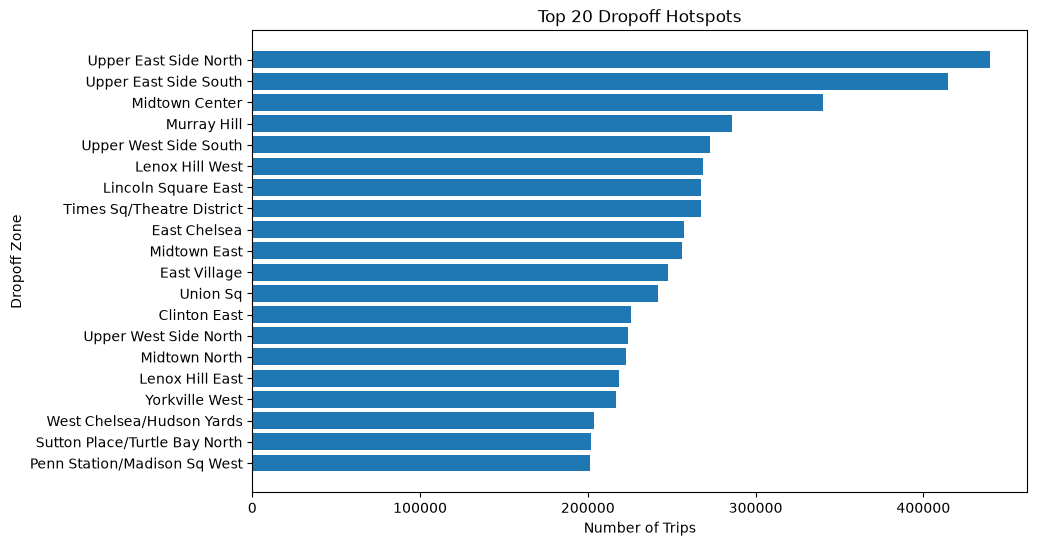

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))

plt.barh(
    top_dropoff["Zone"],
    top_dropoff["trip_count"]
)

plt.gca().invert_yaxis()

plt.xlabel("Number of Trips")
plt.ylabel("Dropoff Zone")
plt.title("Top 20 Dropoff Hotspots")

plt.show()

#### Nhận xét:
1. Zone phổ biến nhất 
- Upper East Side North là khu vực có số lượng chuyến trả khách cao nhất với 439.978 chuyến. Upper East Side North là khu vực có số lượng chuyến trả khách cao nhất, cho thấy đây là điểm đến phổ biến của hành khách sau khi kết thúc chuyến đi. 
- Xếp thứ hai là Upper East Side South với 414.474 chuyến.
- Midtown Center đứng thứ ba với 340.458 chuyến.
2. Mức độ tập trung của nhu cầu:
- Hai khu vực đứng đầu có số chuyến trả khách vượt trội so với phần còn lại. Từ vị trí thứ 4 trở đi, số chuyến giảm dần và dao động trong khoảng 200.000–290.000 chuyến. Khoảng cách giữa nhóm đầu và nhóm cuối khá rõ ràng.
- Nhu cầu trả khách tập trung vào một số khu vực chính. Một số ít zone có lượng chuyến trả khách rất lớn, trong khi các khu vực còn lại có số chuyến giảm dần.
3. Khu vực địa lý nổi bật: Toàn bộ 20/20 khu vực trong Top 20 đều thuộc Manhattan. Các điểm trả khách tập trung gần như hoàn toàn tại Manhattan, cho thấy đây là khu vực có nhu cầu kết thúc chuyến đi cao nhất của thành phố.
4. Cụm trung tâm thương mại: Nhiều khu vực thuộc Top 20 nằm trong khu vực trung tâm Manhattan như:
- Midtown Center
- Midtown East
- Midtown North
- Times Square/Theatre District
- Penn Station/Madison Sq West
- Union Square
- West Chelsea/Hudson Yards
- Đây là những nơi tập trung nhiều văn phòng, trung tâm thương mại, khách sạn và địa điểm du lịch.Các điểm trả khách tạo thành một cụm rõ  rệt quanh trung tâm Manhattan. Điều này phản ánh nhu cầu di chuyển đến các khu vực thương mại, văn phòng và du lịch rất lớn.

=> Manhattan là trung tâm kinh tế, tài chính và du lịch của New York nên thu hút lượng lớn hành khách đến làm việc, mua sắm, tham quan và lưu trú.Các khu vực như Midtown, Times Square, Penn Station và Union Square là những điểm đến quan trọng với nhiều văn phòng, khách sạn, trung tâm thương mại và đầu mối giao thông.

# Origin-Destination Flow 

In [20]:
# Pickup
pickup_lookup = taxi_zone.rename(
    columns={
        "LocationID": "PULocationID",
        "Zone": "pickup_zone"
    }
)


df = df.merge(
    pickup_lookup[
        [
            "PULocationID",
            "pickup_zone"
        ]
    ],
    on="PULocationID",
    how="left"
)

In [21]:
# Dropoff
dropoff_lookup = taxi_zone.rename(
    columns={
        "LocationID": "DOLocationID",
        "Zone": "dropoff_zone"
    }
)


df = df.merge(
    dropoff_lookup[
        [
            "DOLocationID",
            "dropoff_zone"
        ]
    ],
    on="DOLocationID",
    how="left"
)

In [22]:
od_flow = (
    df
    .groupby(
        [
            "pickup_zone",
            "dropoff_zone"
        ]
    )
    .size()
    .reset_index(name="trip_count")
)

In [23]:
top_routes = (
    od_flow
    .sort_values(
        "trip_count",
        ascending=False
    )
)

In [24]:
top_routes.head(20)

,pickup_zone,dropoff_zone,trip_count
42781,Upper East Side South,Upper East Side North,68093
42538,Upper East Side North,Upper East Side South,58500
42537,Upper East Side North,Upper East Side North,45652
42782,Upper East Side South,Upper East Side South,44065
28364,Midtown Center,Upper East Side South,29789
42708,Upper East Side South,Midtown Center,26922
43246,Upper West Side South,Upper West Side North,24985
28363,Midtown Center,Upper East Side North,24935
24792,Lincoln Square East,Upper West Side South,24535
24544,Lenox Hill West,Upper East Side North,23497


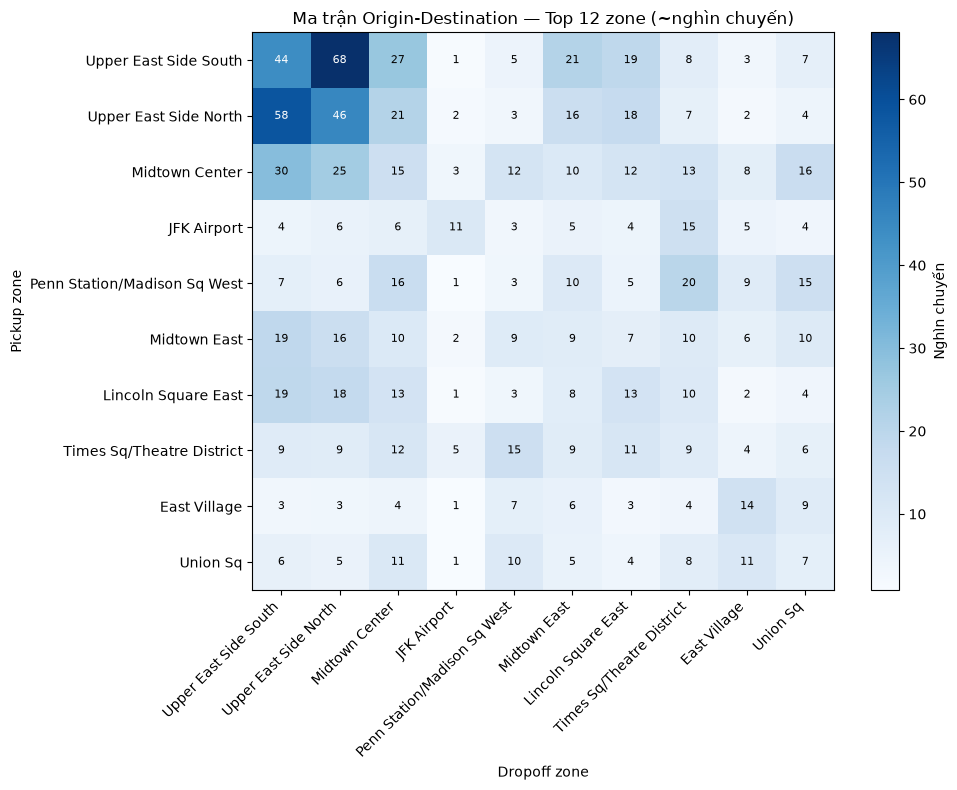

In [25]:
# Heatmap ma trận Origin-Destination — Top 10 zone
import matplotlib.pyplot as plt

# Top 10 zone theo lượng đón
top_zones = (
    df["pickup_zone"]
    .value_counts()
    .head(10)
    .index
    .tolist()
)

# Ma trận O-D giữa các zone này (nghìn chuyến)
od = od_flow[
    od_flow["pickup_zone"].isin(top_zones)
    & od_flow["dropoff_zone"].isin(top_zones)
]

matrix = (
    od.pivot_table(
        index="pickup_zone",
        columns="dropoff_zone",
        values="trip_count",
        aggfunc="sum",
        fill_value=0,
    )
    .reindex(index=top_zones, columns=top_zones, fill_value=0)
)

M = matrix.to_numpy() / 1000  # nghìn chuyến

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(M, cmap="Blues", aspect="auto")

ax.set_xticks(range(len(top_zones)))
ax.set_yticks(range(len(top_zones)))
ax.set_xticklabels(top_zones, rotation=45, ha="right")
ax.set_yticklabels(top_zones)

ax.set_xlabel("Dropoff zone")
ax.set_ylabel("Pickup zone")
ax.set_title("Ma trận Origin-Destination — Top 10 zone (~nghìn chuyến)")

# Ghi số vào từng ô
for i in range(M.shape[0]):
    for j in range(M.shape[1]):
        if M[i, j] >= 0.5:
            ax.text(
                j, i, f"{M[i, j]:.0f}",
                ha="center", va="center", fontsize=8,
                color="white" if M[i, j] > M.max() * 0.55 else "black",
            )

fig.colorbar(im, ax=ax, label="Nghìn chuyến")
plt.tight_layout()
plt.show()

#### Nhận xét:
- Các tuyến có lưu lượng lớn nhất đều tập trung giữa Upper East Side North và Upper East Side South.
- Phần lớn các tuyến có lưu lượng cao đều nằm trong Manhattan
- Midtown đóng vai trò là một trung tâm kết nối quan trọng trong mạng lưới di chuyển bằng taxi.
- Trong Top 20 tuyến chỉ có duy nhất một tuyến liên quan sân bay là JFK Airport → Outside of NYC, và tuyến này chỉ xếp thứ 19 (19.415 chuyến). Top 10 tuyến không có tuyến sân bay nào => phần lớn chuyến taxi là nhu cầu đi lại hàng ngày trong nội đô, trong khi các chuyến đi sân bay có tần suất thấp hơn.


# Airport Analysis

In [26]:
taxi_zone["service_zone"].value_counts()

service_zone
Boro Zone      205
Yellow Zone     55
Airports         2
Unknown          2
EWR              1
Name: count, dtype: int64

In [27]:
airport_zones = (
    taxi_zone[
        taxi_zone["service_zone"].isin(["Airports", "EWR"])
    ]["LocationID"]
    .tolist()
)

In [28]:
airport_trips = df[
    (df["PULocationID"].isin(airport_zones)) |
    (df["DOLocationID"].isin(airport_zones))
].copy()

In [29]:
non_airport_trips = df[
    (~df["PULocationID"].isin(airport_zones)) &
    (~df["DOLocationID"].isin(airport_zones))
].copy()

In [30]:
airport_percentage = (
    len(airport_trips) / len(df)
) * 100

print(f"% trips liên quan airport: {airport_percentage:.2f}%")

% trips liên quan airport: 7.67%


In [31]:
# Fare trung bình
airport_avg_fare = airport_trips["fare_amount"].mean()

In [32]:
fare_compare = pd.DataFrame({
    "Trip Type": [
        "Airport",
        "Non-Airport"
    ],
    "Average Fare": [
        airport_trips["fare_amount"].mean(),
        non_airport_trips["fare_amount"].mean()
    ]
})

fare_compare

,Trip Type,Average Fare
0,Airport,56.369279
1,Non-Airport,18.511107


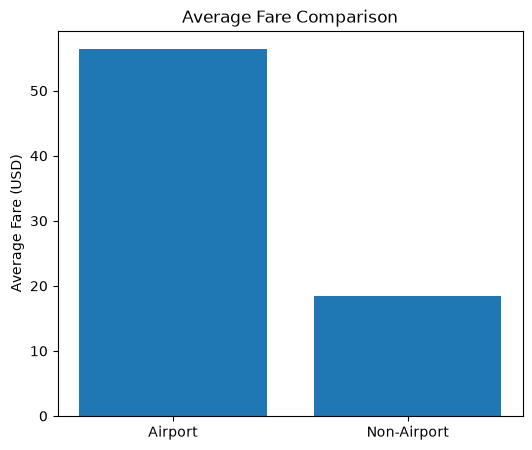

In [33]:
plt.figure(figsize=(6,5))

plt.bar(
    fare_compare["Trip Type"],
    fare_compare["Average Fare"]
)

plt.ylabel("Average Fare (USD)")
plt.title("Average Fare Comparison")

plt.show()

#### Nhận xét: 
- Giá cước trung bình của các chuyến đi liên quan đến sân bay là 56,37 USD, trong khi các chuyến không liên quan đến sân bay chỉ có giá cước trung bình 18,51 USD. Như vậy, giá cước của các chuyến đi sân bay cao gấp khoảng 3,05 lần so với các chuyến đi thông thường.
- Sự chênh lệch này có thể do:
	+ Các chuyến đi sân bay thường có quãng đường di chuyển dài hơn, chủ yếu giữa sân bay và khu vực trung tâm hoặc các khu dân cư trong thành phố.
	+ Thời gian di chuyển thường dài hơn do khoảng cách xa và có thể chịu ảnh hưởng của tình trạng giao thông.

     Trip Type  Average Total
0      Airport      77.914217
1  Non-Airport      26.164240


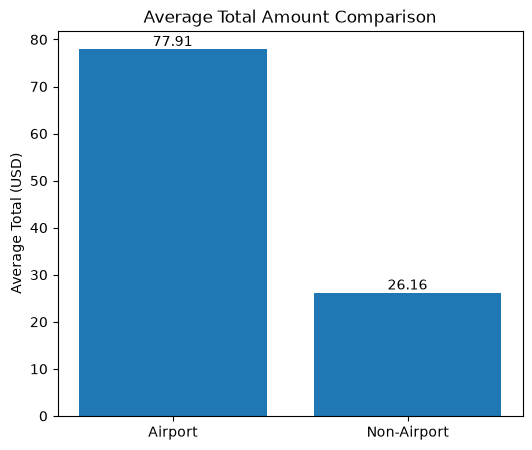

In [34]:
# So sánh tổng tiền thực trả (total_amount)
import pandas as pd 
import matplotlib.pyplot as plt
total_compare = pd.DataFrame({
    "Trip Type": [
        "Airport",
        "Non-Airport"
    ],
    "Average Total": [
        airport_trips["total_amount"].mean(),
        non_airport_trips["total_amount"].mean()
    ]
})

print(total_compare)

plt.figure(figsize=(6,5))

bars = plt.bar(
    total_compare["Trip Type"],
    total_compare["Average Total"]
)

plt.bar_label(bars, fmt="{:,.2f}")

plt.ylabel("Average Total (USD)")
plt.title("Average Total Amount Comparison")

plt.show()

#### Nhận xét:
- Tổng tiền trung bình của chuyến sân bay là **77,91 USD**, so với **26,16 USD** ở chuyến thông thường — cao gấp khoảng **2,98 lần**.
- So với chênh lệch ở `fare_amount` (3,05 lần), tỷ lệ trên `total_amount` gần tương đương, cho thấy phần lớn chênh lệch đến từ **cước cơ bản do quãng đường dài**, còn các khoản phụ phí sân bay chỉ đóng góp thêm một phần nhỏ vào tổng tiền.


In [35]:
airport_avg_distance = airport_trips["trip_distance"].mean()
print(airport_avg_distance)

13.070377836078498


In [36]:
# Distance trung bình
distance_compare = pd.DataFrame({
    "Trip Type": [
        "Airport",
        "Non-Airport"
    ],
    "Average Distance": [
        airport_trips["trip_distance"].mean(),
        non_airport_trips["trip_distance"].mean()
    ]
})

distance_compare

,Trip Type,Average Distance
0,Airport,13.070378
1,Non-Airport,2.682250


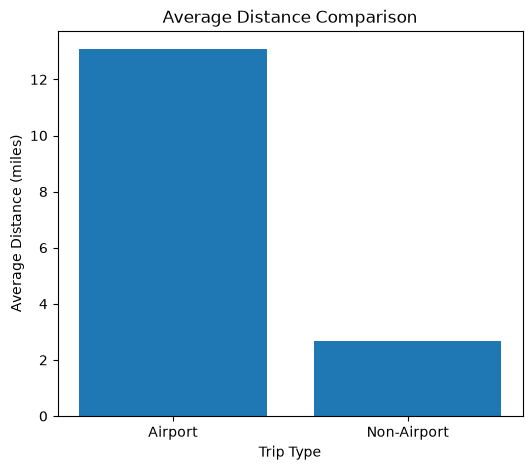

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,5))
plt.bar(
    distance_compare["Trip Type"],
    distance_compare["Average Distance"]
)

plt.ylabel("Average Distance (miles)")
plt.title("Average Distance Comparison")
plt.xlabel("Trip Type")
plt.show()

#### Nhận xét:
- Quãng đường trung bình của các chuyến đi liên quan đến sân bay là 13,07 miles, trong khi các chuyến không liên quan đến sân bay chỉ có quãng đường trung bình 2,68 miles. Như vậy, quãng đường của các chuyến đi sân bay dài gấp khoảng 4,87 lần so với các chuyến đi thông thường.
- Sự khác biệt này phản ánh đặc điểm vị trí của các sân bay (JFK, LaGuardia và Newark), vốn nằm cách khá xa khu vực trung tâm Manhattan và nhiều khu dân cư. Do đó, hành khách thường phải di chuyển quãng đường dài hơn khi đến hoặc rời sân bay. Quãng đường di chuyển dài hơn cũng là một trong những nguyên nhân chính khiến giá cước trung bình của các chuyến đi sân bay cao hơn đáng kể so với các chuyến đi không liên quan đến sân bay. 

In [38]:
airport_summary = pd.DataFrame(
    {
        "metric":[
            "Airport trip percentage",
            "Airport avg fare",
            "Non-airport avg fare",
            "Airport avg distance",
            "Non-airport avg distance"
        ],
        "value":[
            airport_percentage,
            airport_avg_fare,
            non_airport_trips["fare_amount"].mean(),
            airport_avg_distance,
            non_airport_trips["trip_distance"].mean()
        ]
    }
)

airport_summary

,metric,value
0,Airport trip percentage,7.674607
1,Airport avg fare,56.369279
2,Non-airport avg fare,18.511107
3,Airport avg distance,13.070378
4,Non-airport avg distance,2.682250
